# 02 · Dimensional scaling: does the PINN escape the curse of dimensionality?

This notebook loads the results produced by
`python experiments/dimensional_scaling.py` and interprets them. Re-run that script to regenerate the CSVs.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import src` works
import numpy as np, matplotlib.pyplot as plt
from src.utils import set_plot_style, CB
set_plot_style()
import pandas as pd

In [3]:
fdm = pd.read_csv('../results/scaling/fdm_scaling.csv')
pinn = pd.read_csv('../results/scaling/pinn_scaling.csv')
display(fdm); display(pinn)

,dim,n_per_dim,n_grid,feasible,runtime_s,memory_MB,E0,E0_exact,energy_error
0,1,40,40,True,0.005420,0.001580,0.497024,0.5,0.002976
1,2,40,1600,True,0.008718,0.100484,0.994047,1.0,0.005953
2,3,40,64000,True,0.363104,5.516804,1.491071,1.5,0.008929
3,4,40,2560000,False,NaN,368.640000,NaN,2.0,NaN
4,5,40,102400000,False,NaN,18022.400000,NaN,2.5,NaN


,dim,n_collocation,n_params,epochs,train_time_mean_s,inference_time_s,energy_error_mean,energy_error_std,energy_error_min,n_seeds
0,1,2000,8514,1200,9.310751,0.001493,0.039966,0.008676,0.029454,3
1,2,2000,8578,1200,14.268784,0.001503,0.302797,0.027895,0.264069,3
2,3,2000,8642,1200,20.935221,0.001444,0.143413,0.068817,0.085009,3
3,4,2000,8706,1200,45.219995,0.001452,0.857975,0.000615,0.857105,3


## The finite-difference grid explodes as $N=n^d$
With $n$ points per axis fixed, the grid grows exponentially in $d$ and quickly becomes infeasible in memory -- the curse of dimensionality made concrete.

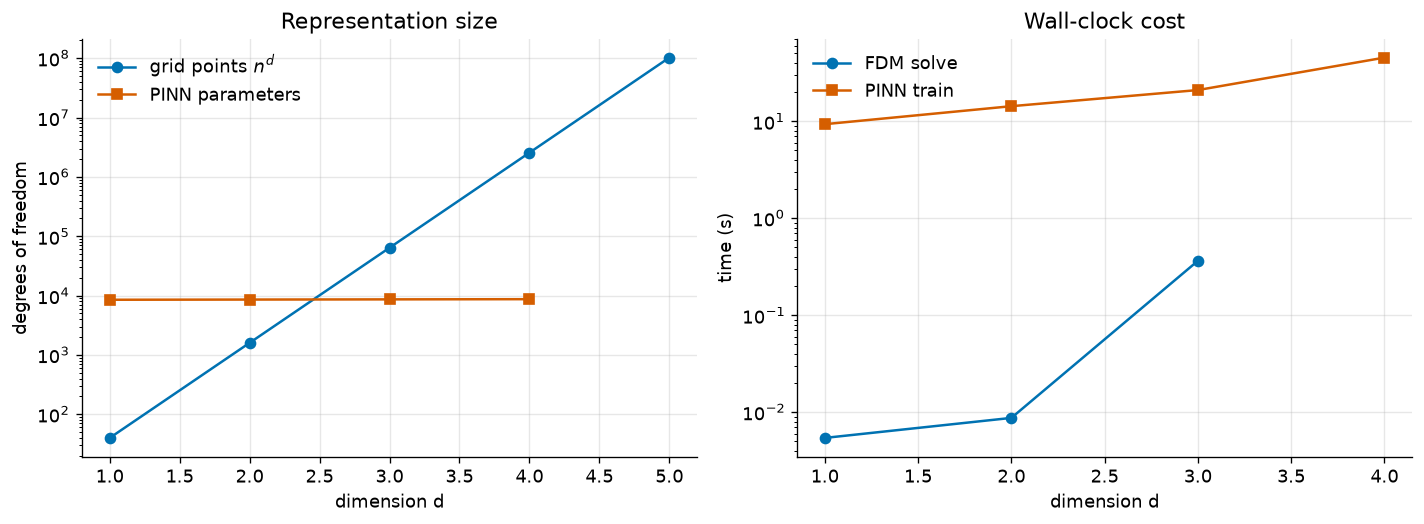

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].semilogy(fdm['dim'], fdm['n_grid'], 'o-', color=CB['blue'], label='grid points $n^d$')
ax[0].semilogy(pinn['dim'], pinn['n_params'], 's-', color=CB['red'], label='PINN parameters')
ax[0].set_xlabel('dimension d'); ax[0].set_ylabel('degrees of freedom'); ax[0].legend()
ax[0].set_title('Representation size')
feas = fdm[fdm['feasible']]
ax[1].semilogy(feas['dim'], feas['runtime_s'], 'o-', color=CB['blue'], label='FDM solve')
ax[1].semilogy(pinn['dim'], pinn['train_time_mean_s'], 's-', color=CB['red'], label='PINN train')
ax[1].set_xlabel('dimension d'); ax[1].set_ylabel('time (s)'); ax[1].legend()
ax[1].set_title('Wall-clock cost')
fig.tight_layout(); plt.show()

## But avoiding the grid is not the same as solving the problem
The PINN runs at every dimension, but its **accuracy degrades and becomes erratic** as $d$ grows -- optimization and collocation coverage get harder. Avoiding an explicit $n^d$ grid does **not** eliminate the curse of dimensionality; it relocates it into the optimization.

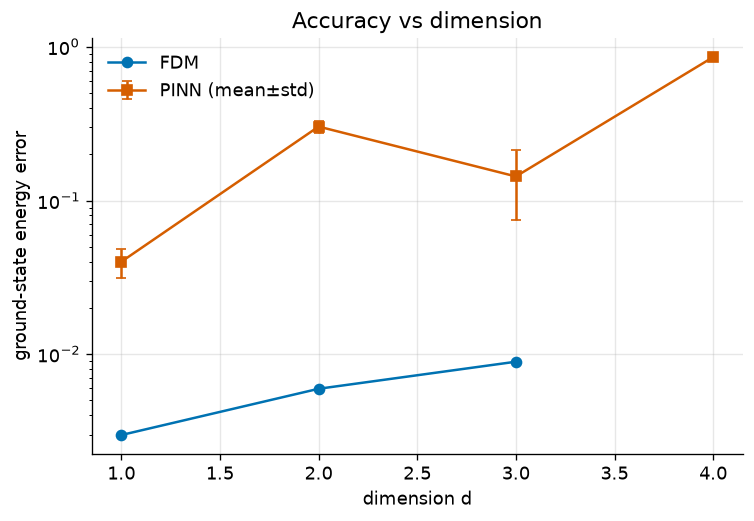

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
feas = fdm[fdm['feasible']]
ax.semilogy(feas['dim'], feas['energy_error'], 'o-', color=CB['blue'], label='FDM')
ax.errorbar(pinn['dim'], pinn['energy_error_mean'], yerr=pinn['energy_error_std'],
            fmt='s-', color=CB['red'], capsize=3, label='PINN (mean±std)')
ax.set_xlabel('dimension d'); ax.set_ylabel('ground-state energy error'); ax.legend()
ax.set_title('Accuracy vs dimension'); plt.show()

See `results/scaling/scaling.png` for the full three-panel figure and `results/scaling/scaling.json` for the exact budgets and hardware.